In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def fetch_housing_data():
    # 1. Create a folder path to save our data
    tarball_path = Path("datasets/housing/housing.tgz")
    
    # 2. Check if the file already exists
    if not tarball_path.is_file():
        Path("datasets/housing").mkdir(parents=True, exist_ok=True)
        
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        
        # 3. Unzip the file. 
        # FIX: We now extract to just "datasets" because the zip file already contains a "housing" folder!
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
            
    # 4. Read the unzipped text file into our Pandas spreadsheet
    return pd.read_csv(Path("datasets/housing/housing.csv"))

# Run the function
housing = fetch_housing_data()

In [2]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

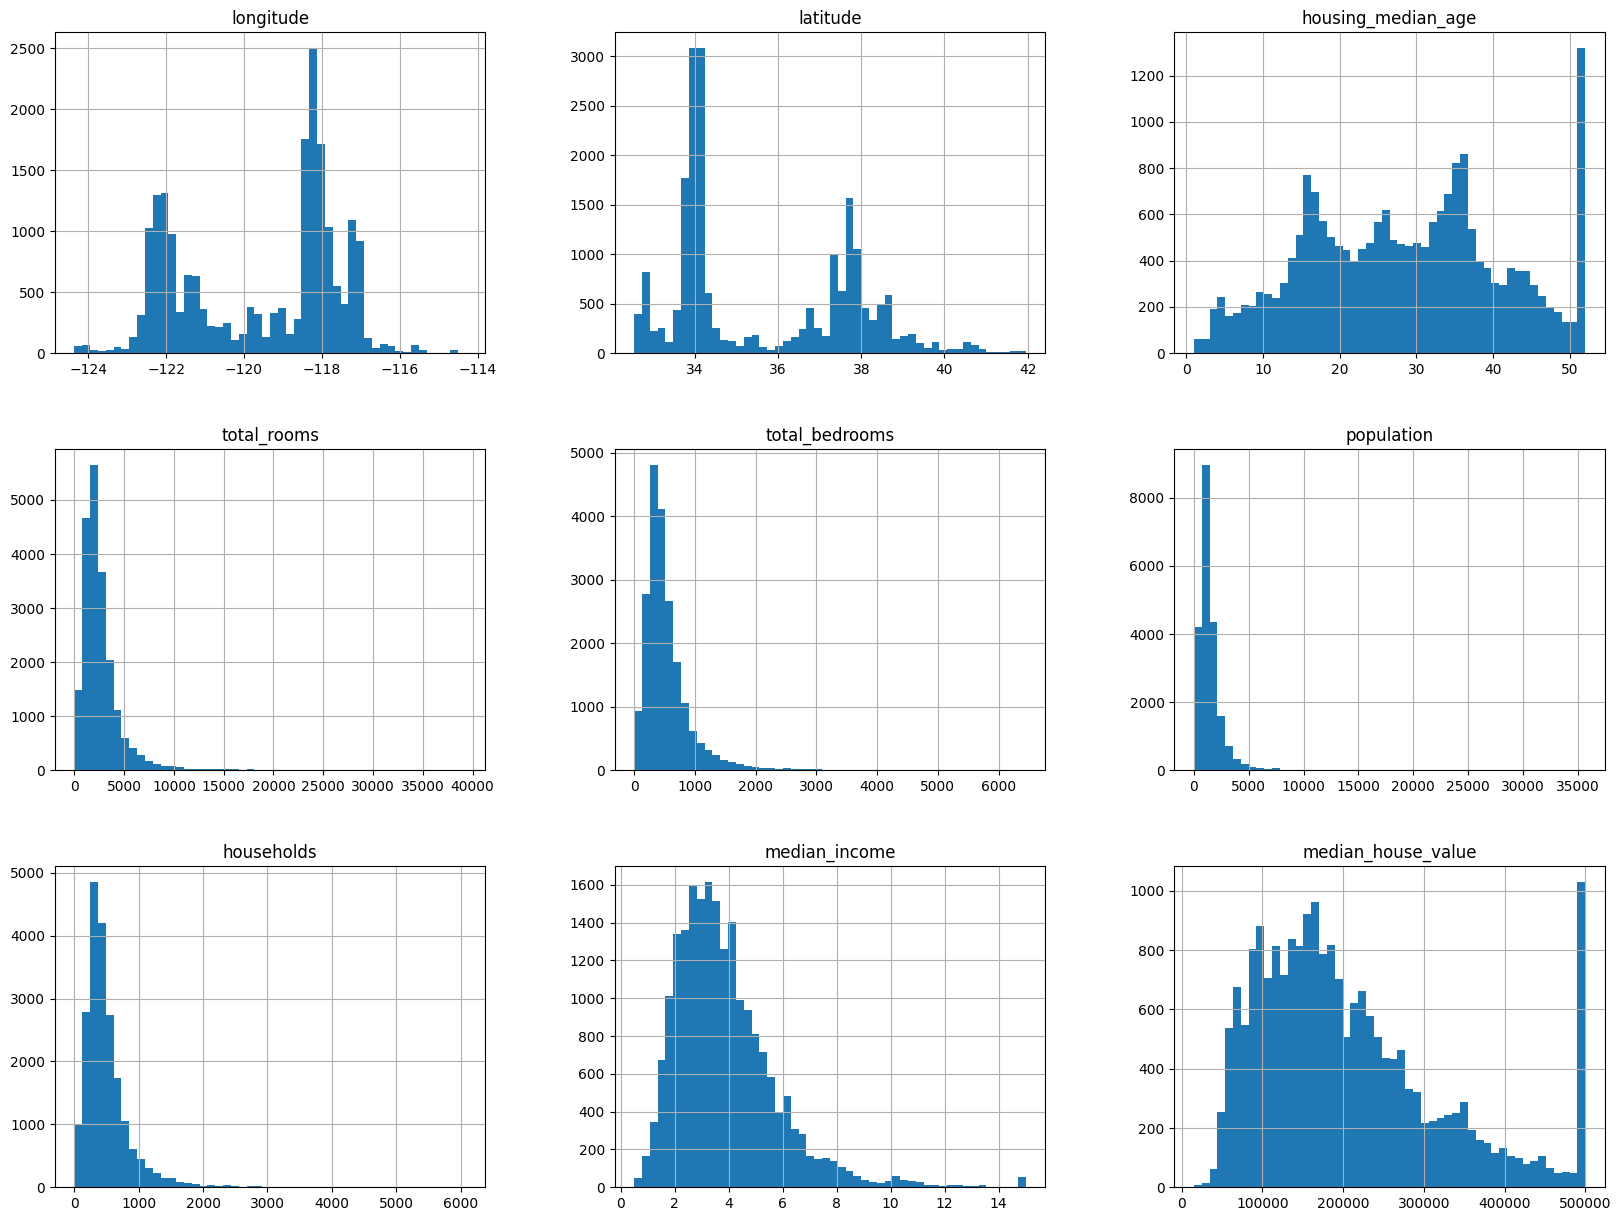

In [6]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(20,15))
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

len(train_set), len(test_set)

(16512, 4128)

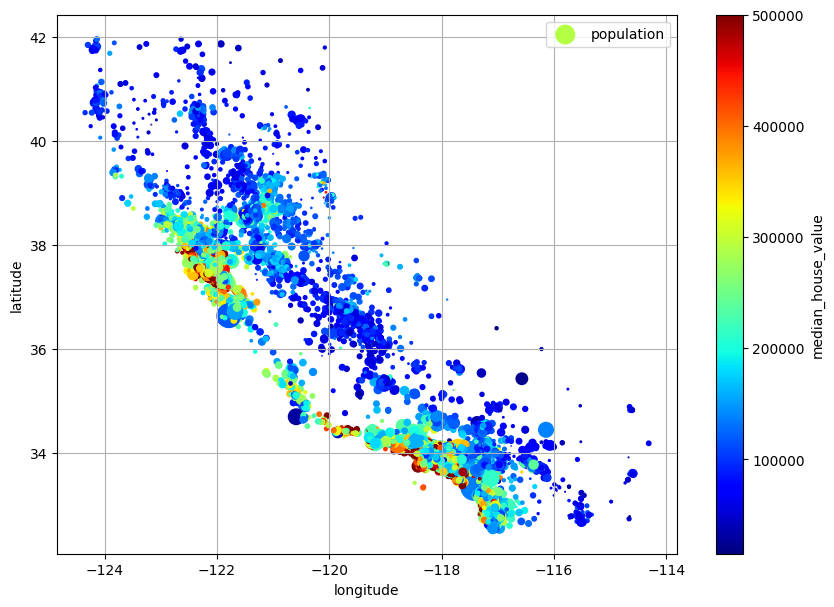

In [8]:
# make a copy of training set

housing_explore = train_set.copy()

# create a plot for analysis
housing_explore.plot(kind="scatter", x = "longitude", y = "latitude", grid=True, s=housing_explore["population"]/100, label="population", figsize=(10,7), c="median_house_value", cmap="jet", colorbar=True, legend=True, sharex=False)
plt.show()

In [9]:
# Corelate every feature with the median price
corr_matrix = housing_explore.corr(numeric_only=True)

print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.687013
total_rooms           0.134060
housing_median_age    0.104714
households            0.065798
total_bedrooms        0.049993
population           -0.025820
longitude            -0.043603
latitude             -0.146324
Name: median_house_value, dtype: float64


<Axes: xlabel='median_income', ylabel='median_house_value'>

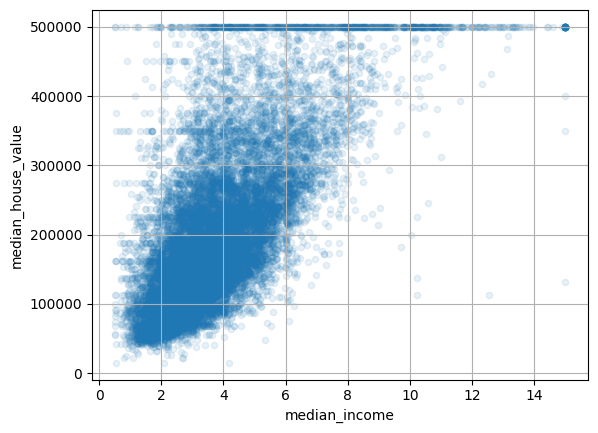

In [10]:
housing_explore.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid="True")

In [11]:
# Feature engineering
housing_explore["rooms_per_household"] = housing_explore["total_rooms"]/housing_explore["households"]
housing_explore["bedrooms_per_room"] = housing_explore["total_bedrooms"]/housing_explore["total_rooms"]
housing_explore["population_per_household"] = housing_explore["population"]/housing_explore["households"]

corr_matrix = housing_explore.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value          1.000000
median_income               0.687013
rooms_per_household         0.146940
total_rooms                 0.134060
housing_median_age          0.104714
households                  0.065798
total_bedrooms              0.049993
population_per_household   -0.021577
population                 -0.025820
longitude                  -0.043603
latitude                   -0.146324
bedrooms_per_room          -0.254817
Name: median_house_value, dtype: float64


In [12]:
housing = train_set.drop("median_house_value", axis=1)
housing_labels = train_set["median_house_value"].copy()

In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np

# Create an imputer object using a median strategy
imputer = SimpleImputer(strategy="median")

# Imputer only performs on numerical attributes so create numericaly only dataset
housing_num = housing.select_dtypes(include=[np.number])

imputer.fit(housing_num)

#print calculated medians for each attribute
imputer.statistics_

# transform given median values to fill the missing values in the dataset
X = imputer.transform(housing_num)
